### Итоговый проект Python

##### Источники данные:
- orders.xlsx
- products.xlsx

### Подготовка к анализу

##### Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

##### Доп. настройки

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}'.replace(',', ' '))
plt.rcParams['figure.figsize'] = (12, 6)

##### Импорт данных

In [14]:
orders = pd.read_excel('orders.xlsx')
products = pd.read_excel('products.xlsx')

print('Размер orders:', orders.shape)
print('Размер products:', products.shape)

display(orders.head())
display(products.head())

Размер orders: (3323, 7)
Размер products: (40152, 4)


,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74
3,1517466327,2022-01-13 15:11:12,22199,1,219,219,130
4,1517429157,2022-01-13 19:15:59,22199,1,219,219,130


,product_id,level1,level2,name
0,1,Гигиена,Бритье,Кассеты для бритья Gillette Fusion ProGlide Po...
1,2,Мучные кондитерские изделия,Мучные кондитерские изделия,Печенье Бодрость
2,3,Мясная гастрономия,"Сосиски, сардельки",Сосиски Стародворье
3,4,Чай,Черный чай,Чай Азерчай
4,5,Безалкогольные напитки,Соковая продукция,Морс Valio


##### Предобработка данных

*Во всех заданиях (кроме расчета среднего чека) можно пренебречь товарами, которые указаны в orders, но отсутствуют в products.

In [15]:
# временной формат
orders['accepted_at'] = pd.to_datetime(orders['accepted_at'])

# доп. столбцы
orders['sales_amount'] = orders['price'] * orders['quantity']
orders['cost_amount'] = orders['cost_price'] * orders['quantity']
orders['promo_flag'] = orders['price'] != orders['regular_price']

# в общий дф попали только продукты, присутсвующие в products (выполнение доп. условия* )
df = orders.merge(products, on='product_id', how='inner')

df['sales_amount'] = df['price'] * df['quantity']
df['cost_amount'] = df['cost_price'] * df['quantity']
df['promo_flag'] = df['price'] != df['regular_price']

print('Размер после inner join:', df.shape)
display(df.head(1))

Размер после inner join: (3018, 13)


,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,sales_amount,cost_amount,promo_flag,level1,level2,name
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74,169,74,False,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан


### Задания

##### **1. Определим самую ходовую товарную группу**

In [19]:
category_sales_vlm = (
    df.groupby('level1', as_index=False)
    .agg(sales_volume=('quantity', 'sum'))
    .sort_values('sales_volume', ascending=False)
    .reset_index(drop=True)
)
# количество проданных штук товара в каждой товарной категории
display(category_sales_vlm)

# топ-1 продаваемая категория и количество
top_cat = category_sales_qty.loc[0, 'level1']
top_cat_vlm = category_sales_qty.loc[0, 'sales_volume']

print(f'Самая ходовая товарная группа: {top_cat} ({top_cat_vlm} шт.)')

,level1,sales_volume
0,Безалкогольные напитки,534
1,Молочная продукция,483
2,Свежие овощи,262
3,Кулинария,250
4,Бакалея,239
5,Хлеб и хлебобулочные изделия,218
6,Снэки,212
7,Свежие фрукты,184
8,Замороженная продукция,175
9,Кондитерские изделия,138


Самая ходовая товарная группа: Безалкогольные напитки (534 шт.)


Barchart "Количество проданных штук по товарным категориям"


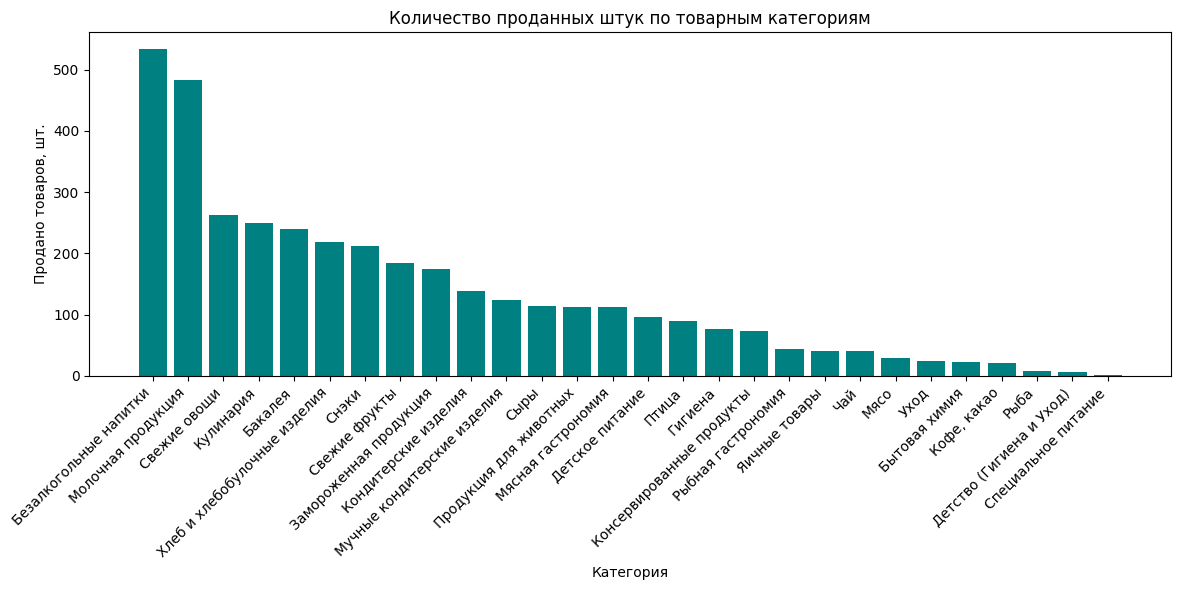

In [24]:
# строим barchart по (продажи по категориям)
plt.figure(figsize=(12, 6))
plt.bar(category_sales_vlm['level1'], category_sales_vlm['sales_volume'], color ='teal')
plt.title('Количество проданных штук по товарным категориям')
plt.xlabel('Категория')
plt.ylabel('Продано товаров, шт.')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 2. Распределение продаж по подкатегориям
Оценим распределение количества проданных позиций в каждой товарной категории (level1) по подкатегориям (level2)

In [26]:
subcat_sales_vlm_distr = (
    df.groupby(['level1', 'level2'], as_index=False)
    .agg(sales_volume=('quantity', 'sum'))
    .sort_values('sales_volume', ascending=False)
    .reset_index(drop=True)
)
display(subcat_sales_vlm_distr)

,level1,level2,sales_volume
0,Безалкогольные напитки,Напитки,252
1,Кулинария,Готовые блюда,248
2,Хлеб и хлебобулочные изделия,Хлеб и хлебобулочные изделия,218
3,Снэки,Снэки соленые,180
4,Безалкогольные напитки,Воды питьевые,162
...,...,...,...
95,Мясная гастрономия,Субпродуктовые изделия,2
96,Уход,Средства по уходу за волосами,2
97,Специальное питание,Диетическое питание,2
98,Бытовая химия,Средства для сантехники,1


##### **3. Посчитаем средний чек на 13.01.2022**
Помним что средний чек считаем по всем товарам orders.

In [35]:
target_date = pd.to_datetime('2022-01-13').date()

# фильтруем по целевому
orders_target_day = orders[orders['accepted_at'].dt.date == target_date].copy()

# cумма по чеку
check_totals = orders_target_day.groupby('order_id', as_index=False).agg(check_amount=('sales_amount', 'sum'))

avg_check = check_totals['check_amount'].mean()

display(check_totals.head(5))
print(f'Средний чек за {target_date.strftime("%d.%m.%Y")}: {avg_check:.2f} руб.')

,order_id,check_amount
0,1517207363,795
1,1517288545,364
2,1517293568,1715
3,1517302077,2096
4,1517305540,342


Средний чек за 13.01.2022: 915.64 руб.


##### **4. Доля промо в категории «Сыры» (в шт).**   

Промо - когда regular_price != price.

In [37]:
# сегменитруем сыр
cheese_df = df[df['level1'] == 'Сыры'].copy()

# ранее создали столбец с флагом промо 'promo_flag'

promo_qty = cheese_df.loc[cheese_df['promo_flag'], 'quantity'].sum()        # количество сыра по промо

nonpromo_qty = cheese_df.loc[~cheese_df['promo_flag'], 'quantity'].sum()    # количество сыра без промо

total_cheese_qty = cheese_df['quantity'].sum()                              # количество сыра всего

promo_share = promo_qty / total_cheese_qty if total_cheese_qty != 0 else 0  # доля промо %

promo_table = pd.DataFrame({
    'group': ['Промо', 'Без промо'],
    'quantity': [promo_qty, nonpromo_qty]
})
promo_table['share'] = promo_table['quantity'] / promo_table['quantity'].sum()

display(promo_table)
print(f'Доля промо в штуках: {promo_share:.2%}')

,group,quantity,share
0,Промо,35,0.31
1,Без промо,79,0.69


Доля промо в штуках: 30.70%


##### График: доля промо в категории «Сыры»

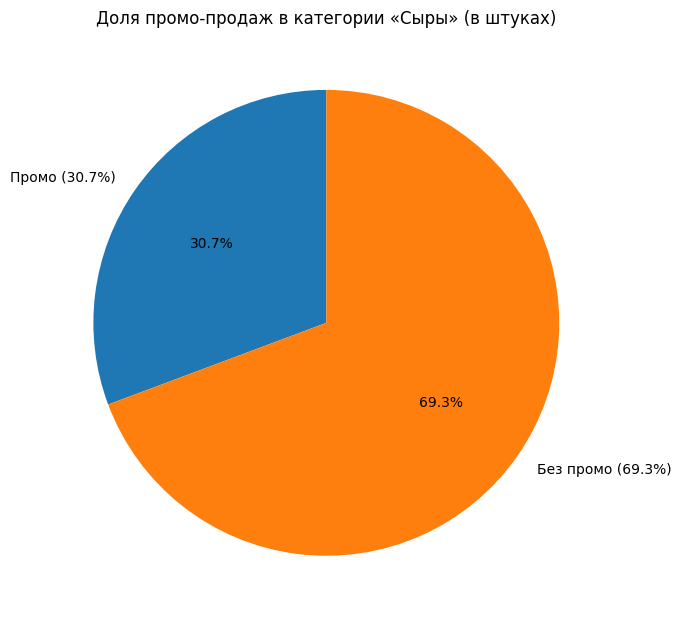

In [38]:
plt.figure(figsize=(7, 7))
plt.pie(
    promo_table['quantity'],
    labels=[f"{row['group']} ({row['share']:.1%})" for _, row in promo_table.iterrows()],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Доля промо-продаж в категории «Сыры» (в штуках)')
plt.tight_layout()
plt.show()

##### **5. Маржа по категориям**
Нужно посчитать маржу:
- В рублях
- В %

In [44]:
margin_by_category = (
    df.groupby('level1', as_index=False)
    .agg(
        sales=('sales_amount', 'sum'),
        costs=('cost_amount', 'sum')
    )
)

margin_by_category['Gross_profit'] = margin_by_category['sales'] - margin_by_category['costs']
margin_by_category['Gross_profit_margin_%'] = np.where(
    margin_by_category['sales'] != 0,
    margin_by_category['Gross_profit'] / margin_by_category['sales'] * 100,
    0
)

display(margin_by_category.sort_values('Gross_profit', ascending=False))

,level1,sales,costs,Gross_profit,Gross_profit_margin_%
1,Безалкогольные напитки,46107,25734,20373,44.19
10,Кулинария,40840,22388,18452,45.18
6,Замороженная продукция,27714,14615,13099,47.26
11,Молочная продукция,37582,25089,12493,33.24
13,Мясная гастрономия,24150,13920,10230,42.36
21,Снэки,22477,12895,9582,42.63
19,Свежие овощи,33222,24216,9006,27.11
0,Бакалея,21766,13589,8177,37.57
20,Свежие фрукты,27009,19130,7879,29.17
23,Сыры,19824,12350,7474,37.70


Графики маржи в рублях и %

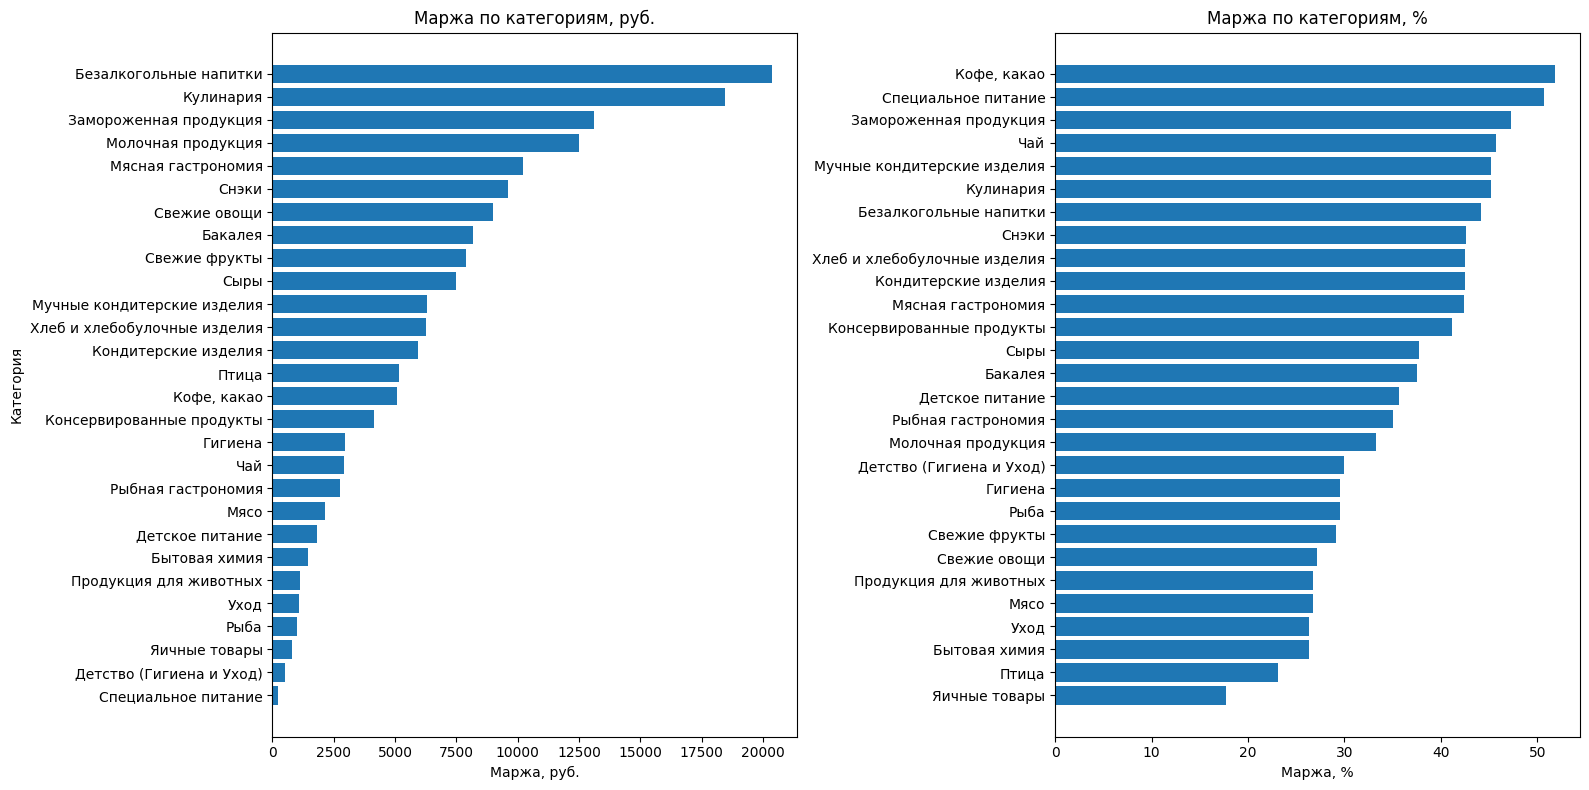

In [47]:
margin_rub_plot = margin_by_category.sort_values('Gross_profit', ascending=True).reset_index(drop=True)
margin_pct_plot = margin_by_category.sort_values('Gross_profit_margin_%', ascending=True).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))  # 1 строка, 2 столбца

# Левый график: маржа в рублях
axes[0].barh(margin_rub_plot['level1'], margin_rub_plot['Gross_profit'])
axes[0].set_title('Маржа по категориям, руб.')
axes[0].set_xlabel('Маржа, руб.')
axes[0].set_ylabel('Категория')

# Правый график: маржа в процентах
axes[1].barh(margin_pct_plot['level1'], margin_pct_plot['Gross_profit_margin_%'])
axes[1].set_title('Маржа по категориям, %')
axes[1].set_xlabel('Маржа, %')
axes[1].set_ylabel('')  # убираем подпись оси Y, чтобы не дублировать

plt.tight_layout()
plt.show()

##### **6. ABC-анализ продаж по подкатегориям**

- по количеству
- по сумме продаж.

После этого формируем итоговую комбинированную группу, например `A C`.

In [66]:
def abc_classific(df, value_col, class_col_name, threshold_a=0.80, threshold_b=0.95):
    if df.empty:
        return df.copy()

    # Проверка на отрицательные значения
    if (df[value_col] < 0).any():
        raise ValueError(f"В колонке '{value_col}' обнаружены отрицательные значения — ABC-анализ не применим.")

    tmp_df = df.copy()
    tmp_df = tmp_df.sort_values(value_col, ascending=False).reset_index(drop=True)

    total = tmp_df[value_col].sum()
    if total == 0:
        # Если вся сумма нулевая — всем присваиваем C (или можно вернуть как есть)
        tmp_df[class_col_name] = 'C'
        tmp_df['share'] = 0.0
        tmp_df['cum_share'] = 0.0
        return tmp_df

    tmp_df['share'] = tmp_df[value_col] / total
    tmp_df['cum_share'] = tmp_df['share'].cumsum()

    tmp_df[class_col_name] = np.select(
        [
            tmp_df['cum_share'] <= threshold_a,
            tmp_df['cum_share'] <= threshold_b
        ],
        ['A', 'B'],
        default='C'
    )

    return tmp_df

In [53]:
abc_base = (
    df.groupby(['level1', 'level2'], as_index=False)
    .agg(
        total_quantity=('quantity', 'sum'),
        total_sales=('sales_amount', 'sum')
    )
)

display(abc_base.head())

,level1,level2,total_quantity,total_sales
0,Бакалея,Все для суши,9,1591
1,Бакалея,Зерновые для завтраков,24,2589
2,Бакалея,Ингредиенты для готовки,21,652
3,Бакалея,"Крупы, бобовые",30,3135
4,Бакалея,Макаронные изделия,24,2388


In [71]:
# классификация по количеству (шт.)
abc_qty = abc_classific(
    abc_base[['level1', 'level2', 'total_quantity']].copy(),
    'total_quantity',
    'abc_qty'
)

# классификация по продажам (руб.)
abc_sales = abc_classific(
    abc_base[['level1', 'level2', 'total_sales']].copy(),
    'total_sales',
    'abc_sales'
)

abc_result = (
    abc_base
    .merge(abc_qty[['level1', 'level2', 'abc_qty']], on=['level1', 'level2'], how='left')
    .merge(abc_sales[['level1', 'level2', 'abc_sales']], on=['level1', 'level2'], how='left')
)

# столбец с двойным рейтингом
abc_result['abc_final'] = abc_result['abc_qty'] + ' ' + abc_result['abc_sales']

abc_result = abc_result.sort_values(
    ['abc_qty', 'abc_sales', 'total_quantity', 'total_sales'],
    ascending=[True, True, False, False]
).reset_index(drop=True)

display(abc_result)

,level1,level2,total_quantity,total_sales,abc_qty,abc_sales,abc_final
0,Безалкогольные напитки,Напитки,252,24123,A,A,A A
1,Кулинария,Готовые блюда,248,40356,A,A,A A
2,Хлеб и хлебобулочные изделия,Хлеб и хлебобулочные изделия,218,14724,A,A,A A
3,Снэки,Снэки соленые,180,17293,A,A,A A
4,Безалкогольные напитки,Воды питьевые,162,9141,A,A,A A
...,...,...,...,...,...,...,...
95,Гигиена,Влажные салфетки,2,255,C,C,C C
96,"Кофе, какао","Какао, горячий шоколад",2,238,C,C,C C
97,Гигиена,Первая помощь,2,168,C,C,C C
98,Бытовая химия,Средства для сантехники,1,239,C,C,C C


Распределение итоговых ABC-групп

In [74]:
abc_group_distribution = (
    abc_result['abc_final']
    .value_counts()
    .rename_axis('Финальный рейтинг')
    .reset_index(name='Количество подкатегорий')
)

display(abc_group_distribution)

,Финальный рейтинг,Количество подкатегорий
0,C C,33
1,A A,23
2,B B,16
3,B A,9
4,C B,9
5,A B,5
6,B C,3
7,A C,2


### Итоговые выводы

In [76]:
print(
    f"ИТОГОВЫЕ ВЫВОДЫ\n"
    f"1. Самая ходовая категория: {top_category} ({top_category_qty} шт.)\n"
    f"2. Средний чек 13.01.2022: {avg_check:.2f} руб.\n"
    f"3. Доля промо в категории «Сыры»: {promo_share:.2%}"
)

ИТОГОВЫЕ ВЫВОДЫ
1. Самая ходовая категория: Безалкогольные напитки (534 шт.)
2. Средний чек 13.01.2022: 915.64 руб.
3. Доля промо в категории «Сыры»: 30.70%
